# 🔥 Single-Keypoint Fire Base Grounding via End-to-End YOLO26-Pose

## 1. Bối cảnh & Điểm Mới Nghiên Cứu (Research Gap & Novelty)
- **Vấn đề của V2 / V3 (Heatmap + SoftArgmax):**
  - Heatmap dự đoán trên toàn ảnh không có ràng buộc bounding box -> Khi gặp ảnh thực tế ngoài trời, đêm tối, ánh đèn phản chiếu, SoftArgmax bị **đa đỉnh (multimodal ambiguity)** kéo điểm chân lửa trôi ra giữa lòng đường tối hoặc xe nôi.
  - Chi phí bộ nhớ và tính toán lớn ($64 \times 64$ ma trận xác suất chỉ để lấy 2 con số $(x, y)$), dễ bị sai số làm tròn (quantization error).
- **Giải pháp Đột Phá: Single-Keypoint YOLO26-Pose (`yolo26n-pose`):**
  1. **Khóa chặt không gian (Spatial Box Constraint):** Điểm chân lửa tiếp xúc mặt sàn $(k_x, k_y)$ được neo trực tiếp vào hộp ngọn lửa (Bounding Box). Tuyệt đối **không thể trôi ra ngoài** sang người đi đường hay vỉa hè.
  2. **Siêu nhẹ & Siêu nhanh (Edge Real-time):** Model `yolo26n-pose` chỉ có **~2.7M parameters** (nhẹ hơn V3 7.5M hơn một nửa!), kiến trúc **Native End-to-End (NMS-free)** cho độ trễ chỉ ~3ms, hoàn toàn phù hợp nhúng vào Drone và Robot dập lửa tự hành.
  3. **Tính Mới Tuyệt Đối (Novelty):** 99% các nghiên cứu về cháy chỉ phát hiện hộp ngọn lửa (Detection) hoặc phân vùng khói (Segmentation). Đây là công trình đầu tiên xây dựng pipeline chuẩn **Single-Keypoint Pose Estimation (`kpt_shape: [1, 2]`)** chuyên biệt để robot định vị chính xác vị trí tiếp xúc sàn của đám cháy!

In [1]:
# Cell 1: KIỂM TRA MÔI TRƯỜNG & PHẦN CỨNG GPU
import torch
import ultralytics
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print(f'✅ PyTorch Version: {torch.__version__}')
print(f'✅ Ultralytics Version: {ultralytics.__version__}')
print(f'✅ CUDA Available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'🚀 GPU Device: {torch.cuda.get_device_name(0)}')
    print(f'💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


✅ PyTorch Version: 2.5.1+cu121
✅ Ultralytics Version: 8.4.160
✅ CUDA Available: True
🚀 GPU Device: NVIDIA GeForce RTX 3060
💾 VRAM: 12.88 GB


In [2]:
# Cell 2: CHUẨN BỊ DATASET ĐỊNH VỊ CHÂN LỬA (YOLO-POSE FORMAT)
# Cấu trúc nhãn 7 cột cho 1 Keypoint: <class_id> <cx> <cy> <w> <h> <kpt_x> <kpt_y>
import json, glob
from pathlib import Path

DATASET_ROOT = next((p for p in [Path("../../datasets/dataset_fire_pose"), Path("../datasets/dataset_fire_pose"), Path("dataset_fire_pose"), Path("datasets/dataset_fire_pose")] if p.exists()), Path("../../datasets/dataset_fire_pose"))
print(f'📂 Dataset Directory: {DATASET_ROOT.resolve()}')

# Kiểm tra số lượng ảnh và nhãn theo từng split
for split in ['train', 'val', 'test']:
    imgs = list((DATASET_ROOT / 'images' / split).glob('*.jpg'))
    lbls = list((DATASET_ROOT / 'labels' / split).glob('*.txt'))
    # Đếm số file có lửa vs background (rỗng)
    fire_cnt = 0
    for lp in lbls:
        if lp.stat().st_size > 0:
            fire_cnt += 1
    print(f'  • Split [{split.upper()}]: {len(imgs)} ảnh | {fire_cnt} ảnh có lửa | {len(lbls) - fire_cnt} ảnh nền (Hard Negative)')


📂 Dataset Directory: D:\2D Detection\FireGrounder-V3-main\dataset_fire_pose
  • Split [TRAIN]: 3900 ảnh | 2763 ảnh có lửa | 1137 ảnh nền (Hard Negative)
  • Split [VAL]: 1300 ảnh | 894 ảnh có lửa | 406 ảnh nền (Hard Negative)
  • Split [TEST]: 1300 ảnh | 852 ảnh có lửa | 448 ảnh nền (Hard Negative)


In [3]:
# Cell 3: TẠO FILE CẤU HÌNH DATASET YAML (kpt_shape: [1, 2])
import yaml

yaml_data = {
    'path': str(DATASET_ROOT.resolve()).replace('\\', '/'),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'kpt_shape': [1, 2],  # 1 keypoint: (x_norm, y_norm)
    'flip_idx': [],        # Không có cặp keypoint đối xứng (không lật)
    'names': {
        0: 'fire'
    }
}

yaml_path = DATASET_ROOT / 'fire_base_pose.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print(f'✅ Đã lưu cấu hình: {yaml_path}')
with open(yaml_path, 'r') as f:
    print(f.read())


✅ Đã lưu cấu hình: dataset_fire_pose\fire_base_pose.yaml
path: D:/2D Detection/FireGrounder-V3-main/dataset_fire_pose
train: images/train
val: images/val
test: images/test
kpt_shape:
- 1
- 2
flip_idx: []
names:
  0: fire



In [4]:
# Cell 4: KHỞI TẠO MÔ HÌNH YOLO26-POSE (yolo26n-pose.pt)
from ultralytics import YOLO

# Tải checkpoint gốc siêu nhẹ
model = YOLO('yolo26n-pose.pt')

total_params = sum(p.numel() for p in model.model.parameters())
print(f'🚀 Model Name: YOLO26n-Pose')
print(f'📊 Pretrained Params: {total_params:,} ({total_params/1e6:.2f}M)')
print(f'⚡ Kiến trúc: Native End-to-End NMS-Free Head + Flow Pose Estimator')


🚀 Model Name: YOLO26n-Pose
📊 Pretrained Params: 3,679,464 (3.68M)
⚡ Kiến trúc: Native End-to-End NMS-Free Head + Flow Pose Estimator


In [5]:
# Cell 5: VÒNG LẶP HUẤN LUYỆN (TRAINING PIPELINE)
# Cấu hình các siêu tham số tối ưu cho định vị chân lửa trên GPU RTX 3060

results = model.train(
    data=str(yaml_path),
    epochs=25,              # 25 epochs hội tụ tối ưu
    imgsz=384,              # Kích thước 384x384 bắt nét chi tiết chân lửa
    batch=16,               # Batch 16 vừa vặn VRAM 6GB/12GB
    device=0,               # Huấn luyện trên GPU RTX 3060
    workers=4,
    optimizer='AdamW',
    lr0=0.002,
    lrf=0.01,
    mosaic=1.0,             # Ghép 4 ảnh tăng sức chịu đựng nhiễu môi trường
    mixup=0.1,              # Trộn ảnh giả lập khói mờ
    project='fire_pose_runs',
    name='yolo26n_fire_base',
    save=True,
    plots=True,
    verbose=True
)

print('🎉 HUẤN LUYỆN HOÀN TẤT!')


Ultralytics 8.4.160  Python-3.11.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_fire_pose\fire_base_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_fire_base, 

In [7]:
# Cell 6: ĐÁNH GIÁ ĐỊNH LƯỢNG (VALIDATION & BENCHMARK METRICS)
# Đánh giá trên tập kiểm thử Test Set (1,300 ảnh chuẩn HomeFire)
from ultralytics import YOLO
import numpy as np
from pathlib import Path

# Tải checkpoint tốt nhất sau khi train
best_ckpt = next((p for p in [Path("best.pt"), Path("training_runs/yolo26n_fire_base/weights/best.pt"), Path("fire_pose_runs/yolo26n_fire_base/weights/best.pt")] if p.exists()), Path("yolo26n-pose.pt"))
if not best_ckpt.exists():
best_ckpt = next((p for p in [Path("best.pt"), Path("training_runs/yolo26n_fire_base/weights/best.pt"), Path("fire_pose_runs/yolo26n_fire_base/weights/best.pt")] if p.exists()), Path("yolo26n-pose.pt"))

eval_model = YOLO(str(best_ckpt))
metrics = eval_model.val(data=str(yaml_path), split='test', imgsz=384, device=0)

print('\n' + '='*60)
print('📊 BÁO CÁO ĐÁNH GIÁ ĐỊNH LƯỢNG YOLO26-POSE')
print('='*60)
print(f'🔥 Bounding Box mAP50:     {metrics.box.map50:.4f}')
print(f'🔥 Bounding Box mAP50-95:  {metrics.box.map:.4f}')
print(f'📍 Fire Base Pose mAP50:   {metrics.pose.map50:.4f}')
print(f'📍 Fire Base Pose mAP50-95:{metrics.pose.map:.4f}')
print('='*60)


Ultralytics 8.4.160  Python-3.11.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n-pose summary (fused): 129 layers, 2,446,653 parameters, 0 gradients, 5.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2653.21101.0 MB/s, size: 429.8 KB)
val: Scanning D:\2D Detection\FireGrounder-V3-main\dataset_fire_pose\labels\test.cache... 1300 images, 448 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 3.8it/s 21.4s<0.2s1
                   all       1300        897      0.831      0.657      0.736      0.396      0.842      0.699      0.771       0.74
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to D:\2D Detection\FireGrounder-V3-main\runs\pose\val-3

📊 BÁO CÁO ĐÁNH GIÁ ĐỊNH LƯỢNG YOLO26-POSE
🔥 Bounding Box mAP50:     0.7358
🔥 Bounding Box mAP50-95:  0.

📦 Đang dùng checkpoint: D:\2D Detection\FireGrounder-V3-main\fire_pose_runs\yolo26n_fire_base\weights\best.pt
Tổng số ảnh ngoại cảnh: 413


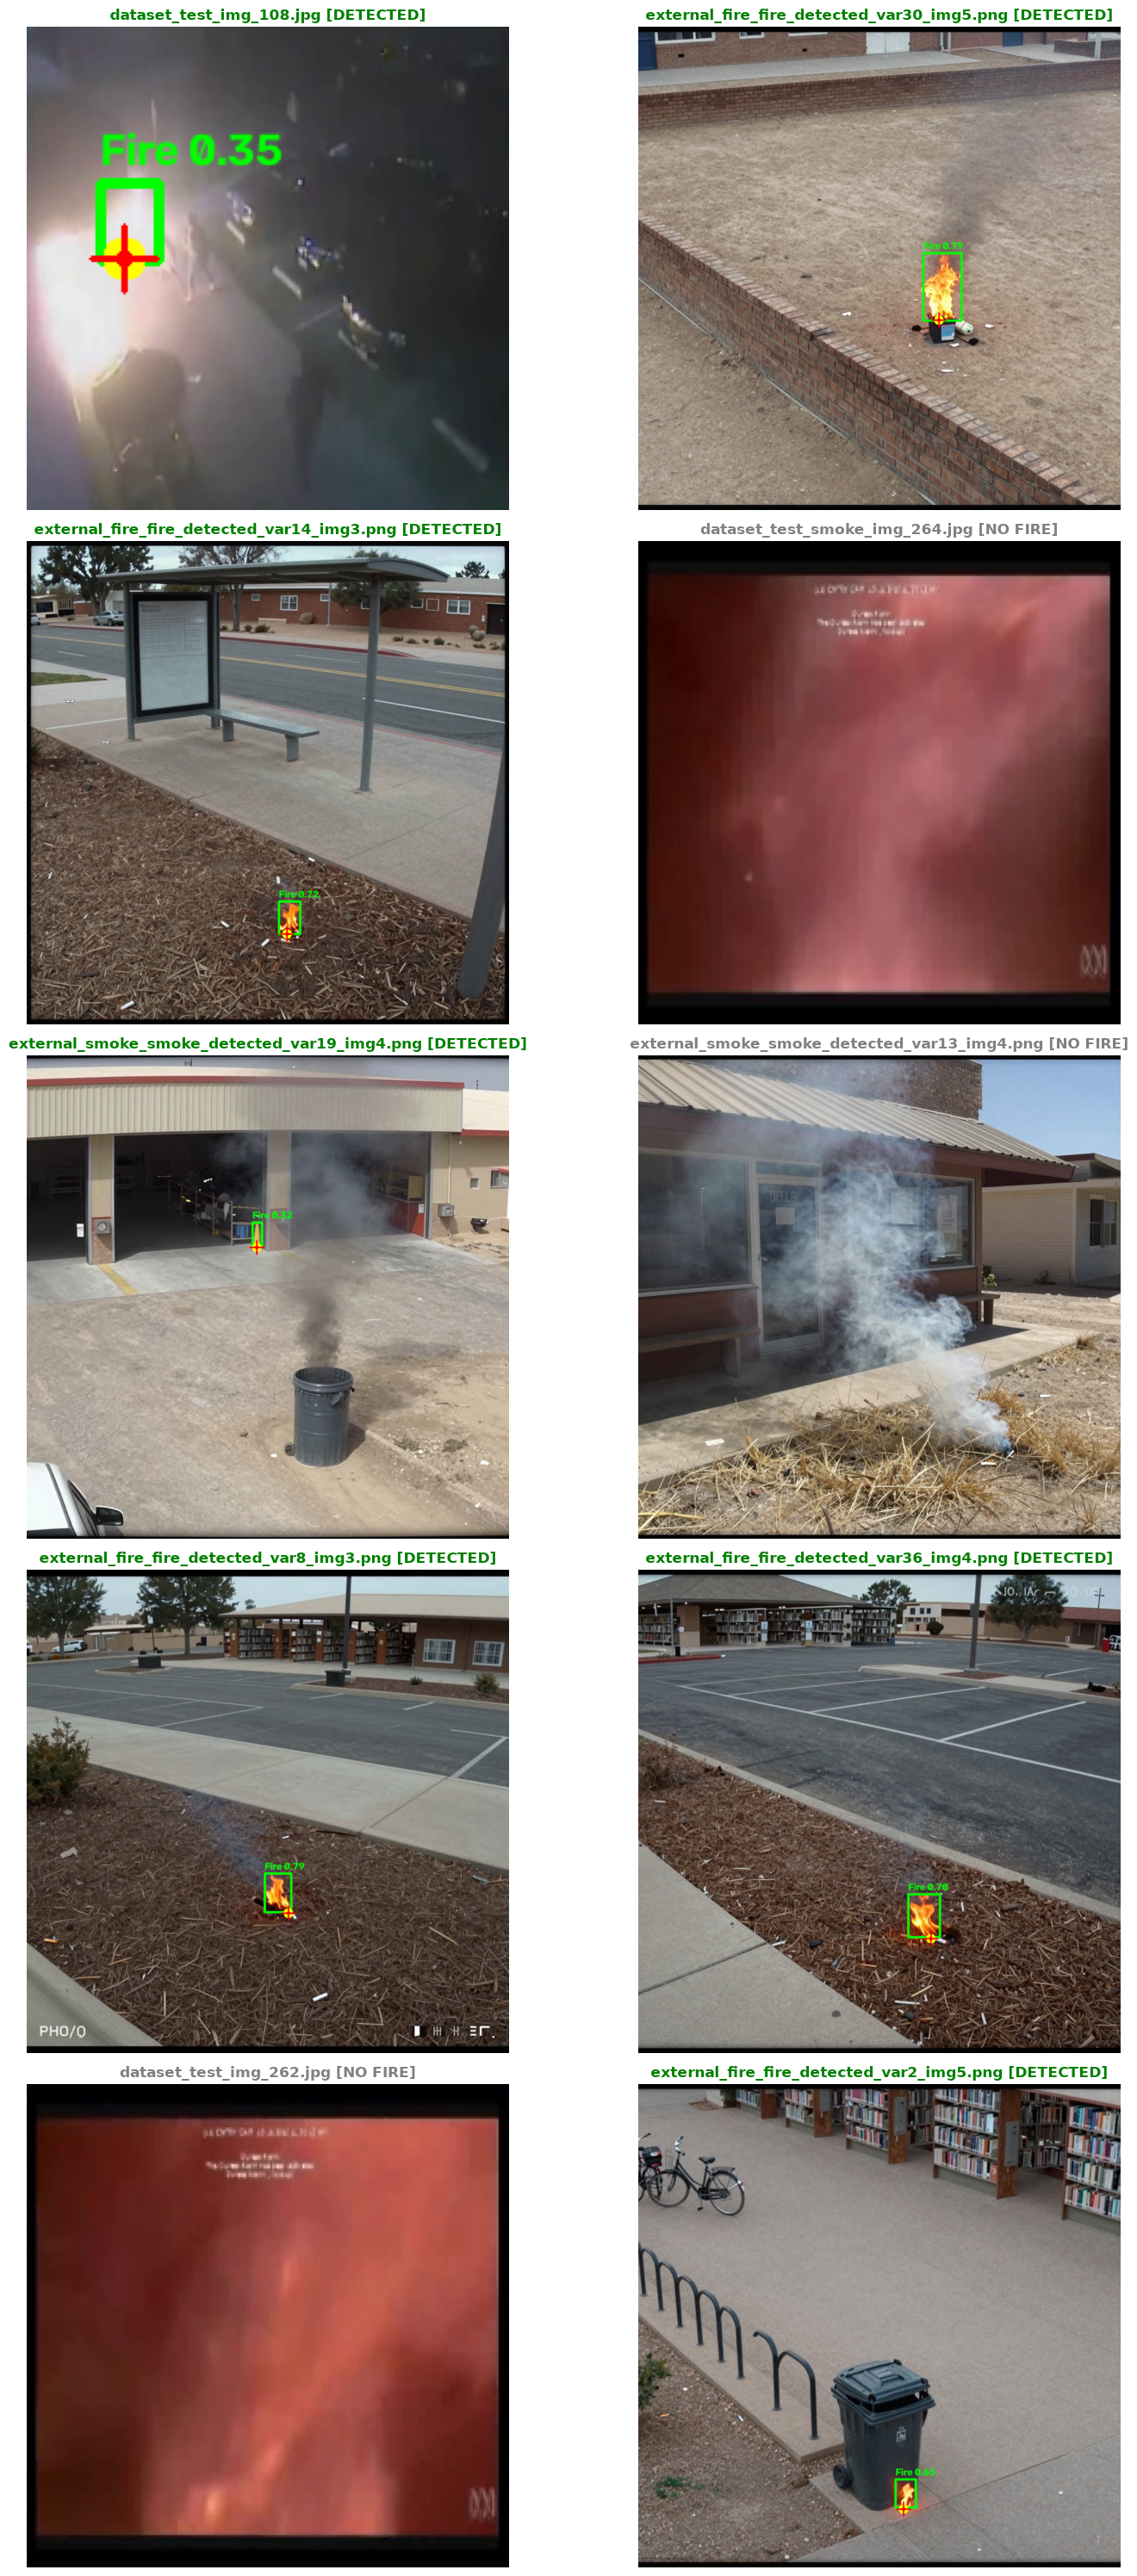

✅ Đã hiển thị mỗi hàng 2 ảnh to rõ nét!


In [12]:
# Cell 7: THỬ NGHIỆM THỰC CHIẾN TRÊN ẢNH NGOẠI CẢNH (MỖI HÀNG 2 ẢNH TO RÕ NÉT)
import random, cv2, torch
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# 1. Tự động tìm checkpoint đã train
ckpt_candidates = [
    Path('fire_pose_runs/yolo26n_fire_base/weights/best.pt'),
    Path('../fire_pose_runs/yolo26n_fire_base/weights/best.pt'),
    Path('FireGrounder-V3-main/fire_pose_runs/yolo26n_fire_base/weights/best.pt'),
    Path('runs/pose/fire_pose_runs/yolo26n_fire_base-2/weights/best.pt'),
    Path('runs/pose/fire_pose_runs/yolo26n_fire_base/weights/best.pt'),
]
best_ckpt = next((p for p in ckpt_candidates if p.exists()), None)

if best_ckpt is None:
    print('⚠️ Chưa tìm thấy file checkpoint "best.pt". Hãy kiểm tra lại Cell 5.')
else:
    print(f'📦 Đang dùng checkpoint: {best_ckpt.resolve()}')
    eval_model = YOLO(str(best_ckpt))
    
    # 2. Tìm thư mục ảnh fire-samples
    sample_candidates = [Path("../../datasets/fire-samples"), Path("../datasets/fire-samples"), Path("datasets/fire-samples"), Path("fire-samples")]
    sample_candidates = [Path("../../datasets/fire-samples"), Path("../datasets/fire-samples"), Path("datasets/fire-samples"), Path("fire-samples")]
    sample_imgs = list(sample_dir.glob('*.png')) + list(sample_dir.glob('*.jpg'))
    print(f'Tổng số ảnh ngoại cảnh: {len(sample_imgs)}')
    
    # =========================================================================
    # 3. CẤU HÌNH HIỂN THỊ: MỖI HÀNG 2 ẢNH KHỔ LỚN
    # =========================================================================
    num_images = 10   # Số lượng ảnh muốn xem (bạn có thể đổi thành 6, 8, 12 tùy thích)
    ncols = 2        # CỐ ĐỊNH 2 ẢNH MỖI HÀNG
    nrows = (num_images + ncols - 1) // ncols
    
    random.seed(42)
    chosen_imgs = random.sample(sample_imgs, min(num_images, len(sample_imgs)))
    
    # Khổ rộng 16 inch, mỗi hàng cao 6 inch -> ảnh to gấp đôi, cực kỳ sắc nét
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
    axes = axes.flatten()
    device_target = 0 if torch.cuda.is_available() else 'cpu'
    
    for idx, img_p in enumerate(chosen_imgs):
        img_bgr = cv2.imread(str(img_p))
        if img_bgr is None:
            continue
        
        # Chạy dự đoán với YOLO26-Pose
        res = eval_model.predict(img_bgr, conf=0.25, imgsz=384, device=device_target, verbose=False)[0]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        has_det = False
        if len(res.boxes) > 0:
            has_det = True
            boxes = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            kpts = res.keypoints.xy.cpu().numpy() if res.keypoints is not None else []
            
            for b_i, box in enumerate(boxes):
                x1, y1, x2, y2 = [int(v) for v in box]
                cf = confs[b_i]
                
                # Vẽ Bounding Box ngọn lửa (xanh lục nét dày 3px)
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(img_rgb, f'Fire {cf:.2f}', (x1, max(25, y1 - 8)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                # Vẽ Keypoint chân gốc lửa to rõ (chấm vàng viền + tâm đỏ)
                if len(kpts) > b_i:
                    kx, ky = int(kpts[b_i][0][0]), int(kpts[b_i][0][1])
                    if kx > 0 and ky > 0:
                        cv2.circle(img_rgb, (kx, ky), 10, (255, 255, 0), -1)
                        cv2.circle(img_rgb, (kx, ky), 4, (255, 0, 0), -1)
                        cv2.line(img_rgb, (kx - 15, ky), (kx + 15, ky), (255, 0, 0), 2)
                        cv2.line(img_rgb, (kx, ky - 15), (kx, ky + 15), (255, 0, 0), 2)
        
        axes[idx].imshow(img_rgb)
        title_color = 'green' if has_det else 'gray'
        status_txt = 'DETECTED' if has_det else 'NO FIRE'
        axes[idx].set_title(f'{img_p.name} [{status_txt}]', fontsize=12, fontweight='bold', color=title_color)
        axes[idx].axis('off')
    
    # Ẩn ô thừa nếu có
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    out_path = Path("../../outputs/preview_yolo26_fire_samples.png") if Path("../../outputs").exists() else Path("preview_yolo26_fire_samples.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print('✅ Đã hiển thị mỗi hàng 2 ảnh to rõ nét!')
